In [1]:
import numpy as np
import numpy.random as rand
import pagn.constants as ct
import matplotlib.pyplot as plt
import pagn
from scipy.stats import uniform

from scipy.stats import rv_continuous

import pandas as pd
import imf
# Space to mess around with Rom et al eqn 15

In [2]:
import binary_formation_distribution_V11 as myscript2
import binary_formation_distribution_V8 as myscript


In [3]:
def r_lc(r, MBH, mbh, mstar):
    sig = (MBH/(3.097*10**8*ct.MSun))**(1/4) * (200 * 1000)
    Rs = 2 * ct.G * MBH/(ct.c**2)
    Rh = ct.G*MBH/(sig**2)

    alpha = 425 * np.pi**2 / (2048 * 2**(1/2) * 1.35 * 10) # Bortolas and Mapelli 2019
    cp = 1.13 #Kaur et al 2024

    rplc=cp * alpha**(2/5) * (mstar/mbh)**(-1/5) * (r/Rh)**(-1/2) 
    return rplc


def R_I_fn(MBH, mbh, mstar, N, Nstar):
    sig = (MBH/(3.097*10**8*ct.MSun))**(1/4) * (200 * 1000)
    f=N/Nstar
    m_ratio=mstar/mbh

    Rh = ct.G*MBH/(sig**2)
    R_I = f**(4/5) * m_ratio**(-6/5) * Rh
    return R_I

def R_II_fn(MBH, mbh, mstar, N, Nstar):
    Rs = 2 * ct.G * MBH/(ct.c**2)

    f=N/Nstar
    m_ratio=mbh/mstar
    fc=4.5e-4*(m_ratio/10)

    R_II  = 4*Rs*(fc/f)**(2/5)

    if R_II<4*Rs:
        R_II=4*Rs
    return R_II

def R_GW_fn(MBH, mbh, mstar, N):
    Rs = 2 * ct.G * MBH/(ct.c**2)
    sig = (MBH/(3.097*10**8*ct.MSun))**(1/4) * (200 * 1000)

    alpha = 425 * np.pi**2 / (2048 * 2**(1/2) * 1.35 * 10) # Bortolas and Mapelli 2019
    cp = 1.13 #Kaur et al 2024
    m_ratio=mstar/mbh

    Rh = ct.G*MBH/(sig**2)

    R_GW = Rs * (10 * alpha**(1/5) / (cp**2))**(4/3) * (m_ratio)**(-2/15) * (Rs/Rh)**(-1/3)
    return R_GW

class RomDistribution(rv_continuous):
    def __init__(self, MBH, mbh, mstar, N, Nstar):
        self.MBH = MBH
        self.mbh = mbh
        self.mstar = mstar
        self.N = N
        self.Nstar = Nstar

    def _pdf(self, r, approx=False):
        MMW=4e6*ct.MSun
        MBH=self.MBH
        mbh=self.mbh
        mstar=self.mstar
        N=self.N
        Nstar = self.Nstar

        Rs = 2 * ct.G * MBH/(ct.c**2)
        
        sig = (MBH/(3.097*10**8*ct.MSun))**(1/4) * (200 * 1000) #M-𝜎 relation Ferrarese and Merrit 2000

        # Nstar = 2*MBH/mstar
        alpha = 425 * np.pi**2 / (2048 * 2**(1/2) * 1.35 * 10) # Bortolas and Mapelli 2019
        cp = 1.13 #Kaur et al 2024

        f=N/Nstar
        # print(f'f: {f}')
        m_ratio=mbh/mstar
        fc=4.5e-4*(m_ratio/10)

        Rh = ct.G*MBH/(sig**2)
        Rc=0.03 * ((mstar/mbh )/ 0.1)**(-2/5)
        R_I = f**(4/5) * m_ratio**(6/5) * Rh
        print((fc/f)**(2/5))
        R_II = 4*Rs*(np.max((1, (fc/f)**(2/5))))
        # R_II=5.5*Rs
        # R_II = r_lc(np.min((R_I, Rc)), MBH, mbh, mstar) * Rs

        C1 = cp**2 / (alpha**(1/5) * 10)
        C2 = np.min(((1, fc/f)))**(4/5) / (alpha*10)

        R_GW = Rs * (10 * alpha**(1/5) / (cp**2))**(4/3) * (m_ratio)**(2/15) * (Rs/Rh)**(-1/3)
        const = 1/(2*np.pi*Rh**3) * (MBH/mstar)

        if approx==True:
            print("APPROX")
            alpha=0.11
            Rs= 4e-7 * ct.pc * (MBH/(MMW))
            Rh=2*ct.pc*(MBH/(MMW))
            R_GW = Rs * 2e3 * (MBH/MMW)
        
        if R_I < r < Rh:
            # print(f'Outer Region, r: {r/Rs:.2e} Rs')
            n = const * f**(9/5) * (mstar/mbh)**(-6/5) * (r/Rh)**(-4)
        elif R_GW < r < R_I:
            # print(f'Outside GW scheme, r: {r/Rs:.2e} Rs')
            n = const * (mstar/mbh)**(3/2) * (r/Rh)**(-7/4)
        elif R_II < r < R_GW:
            # print(f'Inside GW scheme, r: {r/Rs:.2e} Rs')
            n = const * C1 * (mstar/mbh)**(8/5) * (Rs/Rh)**(-3/2) * (r/Rs)**(-1)
        elif Rs <= r < R_II:
            # print(f'Inner Region, r: {r/Rs:.2e} Rs')
            n = const * C2 * f**(4/5) * (mstar/mbh)**(4/5) * (Rs/Rh)**(-3/2) * (r/Rs)
        return n*r*r*np.pi*4
    
def rejection_sample(fn, minimum, maximum, M, N):
    samples=[]
    while len(samples)<N:
        log_uniform_y=rand.uniform(np.log10(minimum), np.log10(maximum))
        uniform_y=10**log_uniform_y
        uniform_u=rand.uniform(0,1)
        # print(uniform_u, uniform_y)
        if uniform_u*M<fn(uniform_y):
            # print(f'uniform_u={uniform_u} accepted')
            samples.append(uniform_y)
    return samples[:N]


def plot_loghist(x, bins, axes, **kwargs):
    hist, bins = np.histogram(x, bins=bins)
    logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
    axes.hist(x, bins=logbins, **kwargs)
    return np.max(hist)


Rs: 3.8e-07 pc
Rh: 9.9e+06 Rs > R_I: 9.9e+04 Rs > R_GW: 2.5e+03 Rs > R_II: 7.3e+00 Rs
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.

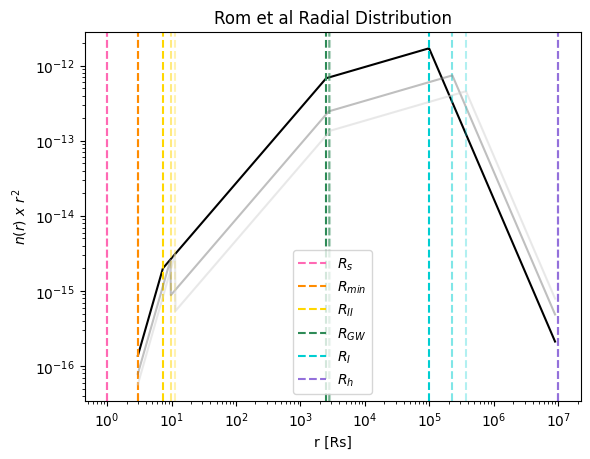

In [ ]:
scaling='Radial'

Mbh=4e6*ct.MSun

mbh=4*ct.MSun
mstar=0.4*ct.MSun

N=2000
Nstar= 20000000
f=N/Nstar

R_g=Mbh * ct.G /(ct.c*ct.c)
Rsch=2*R_g
print(f'Rs: {Rsch/ct.pc:.1e} pc')

R_min = 6*R_g
Rmax=0.1 * ct.pc * (Mbh/(1e6 * ct.MSun))**(1/2)

sig = (Mbh/(3.097*10**8*ct.MSun))**(1/4) * (200 * 1000)
Rh = ct.G*Mbh/(sig**2)

# mbh=8.3*ct.MSun
# mstar=0.4*ct.MSun

Rc=0.03 * ((mstar/mbh)/ 0.1)**(-2/5)

R_GW=R_GW_fn(Mbh, mbh, mstar, N)
R_I=R_I_fn(Mbh, mbh, mstar, N, Nstar)
R_II=R_II_fn(Mbh, mbh, mstar, N, Nstar)
# R_II=r_lc(np.min((R_I, Rc)), Mbh, mbh, mstar)

# print(f'Rh: {Rh/Rsch:.1e} Rs, R_I: {R_I/Rsch:.1e} Rs, R_GW: {R_GW/Rsch:.1e} Rs, R_II: {R_II/Rsch:.1e} Rs, sig: {sig/1000} kms-1\n')
print(f'Rh: {Rh/Rsch:.1e} Rs > R_I: {R_I/Rsch:.1e} Rs > R_GW: {R_GW/Rsch:.1e} Rs > R_II: {R_II/Rsch:.1e} Rs')        

a=RomDistribution(MBH=Mbh, mbh=mbh, mstar=mstar, N=N, Nstar=Nstar)

rs=np.logspace(np.log10(R_min), np.log10(0.9*Rh), 1000)

Rs=[]
N=[]

for r in rs:
    n=a._pdf(r, approx=False)
    Rs.append(r/(2*R_g))
    N.append(n)

plt.plot(Rs, N, color='black')

plt.axvline(x=Rsch/Rsch, linestyle='--', color='hotpink', label='$R_{s}$')
plt.axvline(x=R_min/Rsch, linestyle='--', color='darkorange', label='$R_{min}$')
plt.axvline(x=R_II/Rsch, linestyle='--', color='gold', label='$R_{II}$')
plt.axvline(x=R_GW/Rsch, linestyle='--', color='seagreen', label='$R_{GW}$')
plt.axvline(x=R_I/Rsch, linestyle='--', color='darkturquoise', label='$R_{I}$')
plt.axvline(x=Rh/Rsch, linestyle='--', color='mediumpurple', label='$R_{h}$')

plt.title('Rom et al Radial Distribution')
plt.xlabel('r [Rs]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
# 
plt.ylabel('$n(r)~x~r^2$')
# plt.savefig(f'EMRI_Rates/Rom_radial_dist/Mbh_{Mbh:.1e}_f_{f:.2e}_Radial_dist.pdf')

#########################################################################################################

mbh=8*ct.MSun
mstar=0.4*ct.MSun

N=2000
Nstar= 20000000
f=N/Nstar

R_GW=R_GW_fn(Mbh, mbh, mstar, N)
R_I=R_I_fn(Mbh, mbh, mstar, N, Nstar)
R_II=R_II_fn(Mbh, mbh, mstar, N, Nstar)

print(f'Rh: {Rh/Rsch:.1e} Rs > R_I: {R_I/Rsch:.1e} Rs > R_GW: {R_GW/Rsch:.1e} Rs > R_II: {R_II/Rsch:.1e} Rs')        


plt.axvline(x=Rsch/Rsch, linestyle='--', color='hotpink', label='$R_{s}$', alpha=0.5)
plt.axvline(x=R_min/Rsch, linestyle='--', color='darkorange', label='$R_{min}$', alpha=0.5)
plt.axvline(x=R_II/Rsch, linestyle='--', color='gold', label='$R_{II}$', alpha=0.5)
plt.axvline(x=R_GW/Rsch, linestyle='--', color='seagreen', label='$R_{GW}$', alpha=0.5)
plt.axvline(x=R_I/Rsch, linestyle='--', color='darkturquoise', label='$R_{I}$', alpha=0.5)
plt.axvline(x=Rh/Rsch, linestyle='--', color='mediumpurple', label='$R_{h}$', alpha=0.5)

a=RomDistribution(MBH=Mbh, mbh=mbh, mstar=mstar, N=N, Nstar=Nstar)
rs=np.logspace(np.log10(R_min), np.log10(0.9*Rh), 1000)
Rs=[]
N=[]

for r in rs:
    n=a._pdf(r, approx=False)
    Rs.append(r/(2*R_g))
    N.append(n)

plt.plot(Rs, N, color='grey', alpha=0.5)

#########################################################################################################

#########################################################################################################

mbh=12*ct.MSun
mstar=0.4*ct.MSun

N=2000
Nstar= 20000000
f=N/Nstar

R_GW=R_GW_fn(Mbh, mbh, mstar, N)
R_I=R_I_fn(Mbh, mbh, mstar, N, Nstar)
R_II=R_II_fn(Mbh, mbh, mstar, N, Nstar)

print(f'Rh: {Rh/Rsch:.1e} Rs > R_I: {R_I/Rsch:.1e} Rs > R_GW: {R_GW/Rsch:.1e} Rs > R_II: {R_II/Rsch:.1e} Rs')        


plt.axvline(x=Rsch/Rsch, linestyle='--', color='hotpink', label='$R_{s}$', alpha=0.3)
plt.axvline(x=R_min/Rsch, linestyle='--', color='darkorange', label='$R_{min}$', alpha=0.3)
plt.axvline(x=R_II/Rsch, linestyle='--', color='gold', label='$R_{II}$', alpha=0.3)
plt.axvline(x=R_GW/Rsch, linestyle='--', color='seagreen', label='$R_{GW}$', alpha=0.3)
plt.axvline(x=R_I/Rsch, linestyle='--', color='darkturquoise', label='$R_{I}$', alpha=0.3)
plt.axvline(x=Rh/Rsch, linestyle='--', color='mediumpurple', label='$R_{h}$', alpha=0.3)

a=RomDistribution(MBH=Mbh, mbh=mbh, mstar=mstar, N=N, Nstar=Nstar)
rs=np.logspace(np.log10(R_min), np.log10(0.9*Rh), 1000)
Rs=[]
N=[]

for r in rs:
    n=a._pdf(r, approx=False)
    Rs.append(r/(2*R_g))
    N.append(n)

plt.plot(Rs, N, color='lightgrey', alpha=0.5)

#########################################################################################################

plt.show()

KeyboardInterrupt: 

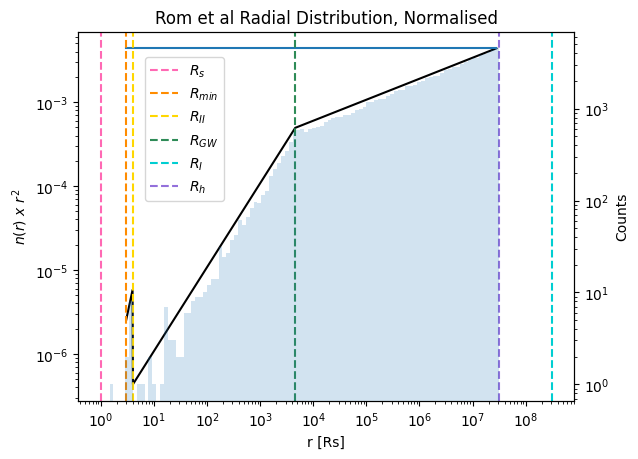

In [ ]:
norm=[float(i)/max(N)for i in N]
maximum=max(Rs)
minimum=min(Rs)
max_norm=max(norm)
unif=uniform.pdf(Rs, minimum, maximum)
M=max(N)/(np.max(list(unif)))
norm_unif=[i*M for i in unif]


samples=rejection_sample(a._pdf, Rsch, Rh, max(N), 100000)
samps=[]

sumN=sum(N)
maxN=max(N)

for sample in samples:
    samps.append(sample/(Rsch))

n=[]
norm=[]

Nsum=sum(N)


for i in range(0, len(Rs)):
    n.append(N[i]/(sumN))
    norm.append(norm_unif[i]/(sumN))

fig, ax1 = plt.subplots()
ax1.plot(Rs, n, color='black')
ax1.plot(Rs, norm)

ax1.axvline(x=Rsch/Rsch, linestyle='--', color='hotpink', label='$R_{s}$')
ax1.axvline(x=R_min/Rsch, linestyle='--', color='darkorange', label='$R_{min}$')
ax1.axvline(x=R_II/Rsch, linestyle='--', color='gold', label='$R_{II}$')
ax1.axvline(x=R_GW/Rsch, linestyle='--', color='seagreen', label='$R_{GW}$')
ax1.axvline(x=R_I/Rsch, linestyle='--', color='darkturquoise', label='$R_{I}$')
ax1.axvline(x=Rh/Rsch, linestyle='--', color='mediumpurple', label='$R_{h}$')
ax1.set_yscale('log')

ax2=ax1.twinx()
plot_loghist(samps, bins=100, axes=ax2, alpha=0.2, label="Sample dist")
ax2.set_ylabel('Counts')

plt.title('Rom et al Radial Distribution, Normalised')
ax1.set_xlabel('r [Rs]')
plt.xscale('log')
plt.yscale('log')
ax1.legend(loc='upper left', bbox_to_anchor=(0.12,0.95))

if scaling=='Radial':
    ax1.set_ylabel('$n(r)~x~r^2$')
    # plt.savefig(f'EMRI_Rates/Rom_radial_dist/Mbh_{Mbh:.1e}_f_{f:.2e}_Radial_dist_normalised_w_hist.pdf')
plt.show()


In [ ]:
Mbh=4e5*ct.MSun

cluster_mass=2 * Mbh/ct.MSun

cluster_tagawa = imf.make_cluster(cluster_mass, massfunc='salpeter', alpha=2.3, mmin=0.1, mmax=140)

cluster=[]
stars=[]

for mass in cluster_tagawa:
    stars.append(mass)
    if mass<20:
        continue
    elif 20<=mass<40:
        mass_bh=mass/4
    elif 40<=mass<=55:
        mass_bh=10
    elif 55<=mass<=120:
        mass_bh=mass/13 + 5.77
    else:
        mass_bh=15
    cluster.append(mass_bh)
    print(f'populating cluster... {len(cluster)}', end='\r')
bh_mass_tot=np.sum(cluster)
print(f'Total bh mass is {bh_mass_tot} MSun, mean is {np.mean(cluster)} MSun')
print(f'stellar mass avg is {np.mean(stars)}')
print(f'f ratio {np.mean(stars)/np.mean(cluster)}')

Total cluster mass is 800001 (limit was 800000)
Total bh mass is 16846.996039208505 MSun, mean is 8.31539784758564 MSun
stellar mass avg is 0.3854839360213777
f ratio 0.046357846381734125


In [46]:
print(len(cluster), len(stars))

2026 2075315


Rs: 3.8e-07 pc
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.8250930256796174
1.82509302567961

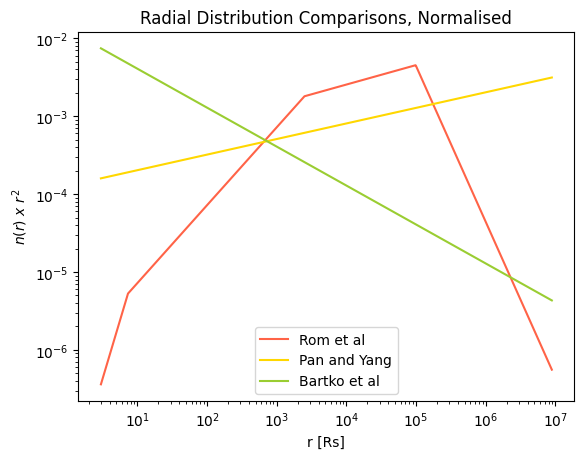

In [13]:
Mbh=4e6*ct.MSun

mbh=4*ct.MSun
mstar=0.4*ct.MSun

N=2000
Nstar= 20000000
f=N/Nstar

R_g=Mbh * ct.G /(ct.c*ct.c)
Rsch=2*R_g
print(f'Rs: {Rsch/ct.pc:.1e} pc')

R_min = 6*R_g
Rmax=0.1 * ct.pc * (Mbh/(1e6 * ct.MSun))**(1/2)

sig = (Mbh/(3.097*10**8*ct.MSun))**(1/4) * (200 * 1000)
Rh = ct.G*Mbh/(sig**2)

a=RomDistribution(MBH=Mbh, mbh=mbh, mstar=mstar, N=N, Nstar=Nstar)

rs=np.logspace(np.log10(R_min/Rsch), np.log10(0.9*Rh/Rsch), 1000)

ns=[]
ns2=[]
Rs=[]
Ns=[]
gamma=-1.8
gamma2=-2.5

for r in rs:
    ns.append((r*Rsch)**(gamma+2))
    ns2.append((r*Rsch)**(gamma2+2))
    n=a._pdf(r*Rsch, approx=False)
    Rs.append(r)
    Ns.append(n)

Norms=[float(i)/sum(Ns)for i in Ns]
norms=[float(i)/sum(ns)for i in ns]
norms2=[float(i)/sum(ns2)for i in ns2]

plt.plot(Rs, Norms, label='Rom et al', color='tomato')
plt.plot(rs, norms, label= 'Pan and Yang', color='gold')
plt.plot(rs, norms2, label = 'Bartko et al', color='yellowgreen')

plt.title('Radial Distribution Comparisons, Normalised')
plt.xlabel('r [Rs]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
# 
plt.ylabel('$n(r)~x~r^2$')

# plt.savefig('EMRI_Rates/Radial_Dist_Comparisons.pdf')
plt.show()


In [15]:
import os

In [24]:
print('printing to file...')

dir_name = f"/Users/pmxks13/PhD/EMRIs_test/EMRI_Rates/"
if not os.path.exists(dir_name):
    os.makedirs(dir_name)
file_name = dir_name+f"EMRI_Rates_Summary.txt"
file = open(file_name, "w")

print('writing params to file...')
file.write(f"MBH/Msun, alpha, le, wind, T_disc/Myr, DT, TT, BIMF, RD, N_tot, N_EMRI\n")
file.close()

printing to file...
writing params to file...


In [ ]:
le=0.01
Mbh=1e6
a=0.1
wind="Off"
T=1e6
DT='SG'
TT='B16'
BIMF="PY"
RD='PY'
N=1000
N_emri=100

file = open(file_name, 'a')
file.write(f'{Mbh} {a} {le} {wind} {T} {DT} {TT} {BIMF} {RD} {N} {N_emri}\n')
file.close()

In [ ]:
le=0.01
Mbh=1e6
a=0.1
wind="Off"
T=1e6
DT='SG'
TT='B16'
BIMF="PY"
RD='PY'
N=1000
N_emri=1000

file = open(file_name, 'a')
file.write(f'{Mbh} {a} {le} {wind} {T} {DT} {TT} {BIMF} {RD} {N} {N_emri}\n')
file.close()